In [1]:
# sphinx_gallery_thumbnail_number = 2

# Authors: Robert Luke <mail@robertluke.net>
#
# License: BSD (3-clause)

# Import common libraries
from collections import defaultdict
from copy import deepcopy
from itertools import compress
from pprint import pprint

# Import Plotting Library
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import os
import pywt


# Import StatsModels
import statsmodels.formula.api as smf
from mne import Epochs, events_from_annotations, set_log_level
from mne.preprocessing.nirs import (
    beer_lambert_law,
    optical_density,
    scalp_coupling_index,
    temporal_derivative_distribution_repair,
    
)

# Import MNE processing
from mne.viz import plot_compare_evokeds

# Import MNE-BIDS processing
from mne_bids import BIDSPath, read_raw_bids


# Import MNE-NIRS processing
from mne_nirs.channels import get_long_channels, picks_pair_to_idx
from mne_nirs.datasets import fnirs_motor_group
from mne_nirs.signal_enhancement import (enhance_negative_correlation, short_channel_regression)
from mne_nirs.channels import (get_long_channels,
                               get_short_channels,
                               picks_pair_to_idx)

from collections import defaultdict
import numpy as np
from itertools import compress
from sklearn.decomposition import PCA
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from mne_bids import BIDSPath
from mne import EpochsArray
from mne.viz import plot_compare_evokeds
from copy import deepcopy
import mne
from statsmodels.formula.api import mixedlm


from scipy.stats import ttest_ind


# Set general parameters
set_log_level("WARNING")  # Don't show info, as it is repetitive for many subjects

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)


# import summary_df from csv file
summary_df = pd.read_csv("global_mean_stddev_zscore.csv")

stats_df = pd.read_csv("individual_mean_stddev_zscore_negcorr.csv")



In [2]:

def individual_analysis(bids_path):
    # Read data with annotations in BIDS format
    raw_intensity = read_raw_bids(bids_path=bids_path, verbose=False)
    
    Breaks, _ = mne.events_from_annotations(raw_intensity, {'Xstart': 4, 'Xend': 5})
    AllEvents, _ = mne.events_from_annotations(raw_intensity)
    Breaks = Breaks[:, 0] / raw_intensity.info['sfreq']
    LastEvent = AllEvents[-1, 0] / raw_intensity.info['sfreq']
    
    if len(Breaks) % 2 == 0:
        raise ValueError("Breaks array should have an odd number of elements.")
    
    original_duration = raw_intensity.times[-1] - raw_intensity.times[0]
    
    cropped_intensity = raw_intensity.copy().crop(Breaks[0], Breaks[1])
    for j in range(2, len(Breaks) - 1, 2):
        block = raw_intensity.copy().crop(Breaks[j], Breaks[j + 1])
        cropped_intensity.append(block)
    cropped_intensity.append(raw_intensity.copy().crop(Breaks[-1], LastEvent + 15.25))
    
    cropped_duration = cropped_intensity.times[-1] - cropped_intensity.times[0]
    
    if cropped_duration >= original_duration:
        print(f"WARNING: Cropping did not reduce duration!")
    
    raw_intensity_cropped = cropped_intensity.copy()

    
    
    # Remove break annotations
    raw_intensity.annotations.delete(np.where(
        (raw_intensity.annotations.description == 'Xstart') | 
        (raw_intensity.annotations.description == 'Xend') | 
        (raw_intensity.annotations.description == 'BAD boundary') | 
        (raw_intensity.annotations.description == 'EDGE boundary')
    )[0])
    
    raw_intensity_cropped.annotations.delete(np.where(
        (raw_intensity_cropped.annotations.description == 'Xstart') | 
        (raw_intensity_cropped.annotations.description == 'Xend') | 
        (raw_intensity_cropped.annotations.description == 'BAD boundary') | 
        (raw_intensity_cropped.annotations.description == 'EDGE boundary')
    )[0]) 
    
    
    
    # Convert signal to optical density and determine bad channels
    raw_od = optical_density(raw_intensity)
    raw_od_cropped = optical_density(raw_intensity_cropped)
    
    # get the total number of short channels
    short_chs = get_short_channels(raw_od)
    tot_number_of_short_channels = len(short_chs.ch_names)
    

    # sci calculated
    sci = scalp_coupling_index(raw_od_cropped, l_freq=0.7, h_freq=1.45)
    bad_channels= list(compress(raw_od.ch_names, sci < 0.8))
    
    if len(bad_channels) > 55:
        print(f"❌ Too many bad channels ({len(bad_channels)}). Excluding subject from analysis.")
        return None, None, None, None, None
    
    raw_od.info["bads"] = bad_channels
    raw_intensity_cropped.info["bads"] = bad_channels
 
    raw_od = temporal_derivative_distribution_repair(raw_od)
    raw_od_cropped = temporal_derivative_distribution_repair(raw_od_cropped)

    
     # Get long channels
    long_chs = get_long_channels(raw_od)
    bad_long_chs = long_chs.info["bads"]
    
    len_bad_short_chs = len(bad_channels) - len(bad_long_chs)
    num_good_short_channels = tot_number_of_short_channels - len_bad_short_chs

    # Determine if there are short channels
    if num_good_short_channels < 4:
        print("❌ No short channels found. Skipping the subject.")
        return None, None, None, None, None # Keep the data unchanged
    else:
        raw_od_corrected = short_channel_regression(raw_od)
        
    
    # Convert to haemoglobin and filter    
        
    raw_haemo = beer_lambert_law(raw_od_corrected, ppf=0.1)
    
    raw_haemo = get_long_channels(raw_haemo, min_dist=0.02) 
    bad_channels_heamo = raw_haemo.info["bads"]
    
    # negative correlation enhancement
    raw_haemo = enhance_negative_correlation(raw_haemo)
    
           
    raw_haemo = raw_haemo.filter(l_freq = None, h_freq = 0.2,  
                                 method="iir", iir_params =dict(order=5, ftype='butter'))
    raw_haemo= raw_haemo.filter(l_freq =  0.05, h_freq = None, method="iir", iir_params =dict(order=5, ftype='butter')) #t0.05 was cutoff in andreas analysis
      
    # Create events and epochs
    events, event_dict = events_from_annotations(
        raw_haemo, verbose=False, regexp="^(?![Ends]).*$"
    )
    epochs = Epochs(
        raw_haemo,
        events,
        event_id=event_dict,
        tmin=-3,
        tmax=14,
        reject=dict(hbo=100e-6),
        reject_by_annotation=True,
        proj=True,
        baseline=(None, 0),
        detrend=1,
        preload=True,
        verbose=None,
    )

    return raw_haemo, epochs, event_dict, raw_od, events, bad_channels_heamo


def reject_epochs_zscore_individual(data, subject, session, condition_name, stats_df, z_thresh=3.0, max_reject_ratio=1.0):
    """
    Rejects epochs based on z-score threshold using subject/session/condition-specific stats from stats_df.

    Parameters:
        data (ndarray): (n_epochs, n_times) or (n_epochs,) averaged data per epoch
        subject (str): e.g., "sub-01"
        session (str): e.g., "ses-01"
        condition_name (str): "Control", "Noise", or "Speech"
        stats_df (pd.DataFrame): DataFrame with per-participant mean and std
        z_thresh (float): Z-score threshold
        max_reject_ratio (float): Max proportion of epochs to reject

    Returns:
        cleaned_data (ndarray), rejected_indices (list)
    """
    row = stats_df[
        (stats_df["Subject"] == f"sub-{subject}") &
        (stats_df["Session"] == f"ses-{session}") &
        (stats_df["Condition"] == condition_name)
    ]

    if row.empty:
        raise ValueError(f"No stats found for {subject}, {session}, {condition_name}")

    mean = row["Mean_Amplitude"].values[0]
    std = row["SD_Amplitude"].values[0]

    z_scores = (data - mean) / std
    reject_mask = np.abs(z_scores) > z_thresh
    rejected_indices = np.where(reject_mask)[0].tolist()

    # Limit rejections
    max_reject = int(max_reject_ratio * data.shape[0])
    if len(rejected_indices) > max_reject:
        rejected_indices = rejected_indices[:max_reject]

    cleaned_data = np.delete(data, rejected_indices, axis=0)
    return cleaned_data, rejected_indices

def full_preprocessing_individual(bids_path, z_thresh=2, stats_df=None):
    
    raw_haemo, epochs, event_dict, raw_od, events, bad_channels = individual_analysis(bids_path)

    if raw_haemo is None or epochs is None or len(epochs) < 10:
        print(f"⚠️ Skipping {bids_path.basename} (insufficient or failed data)")
        return None

    sub = bids_path.subject
    ses = bids_path.session

    # Drop bad channels, pick HbO only, and crop
    epochs.drop_channels(epochs.info['bads'])
    epochs_cleaned = epochs.copy().pick("hbo")
    #epochs_cleaned.crop(tmin=0.0, tmax=10.0)

    # Prepare data for rejection
    #data = epochs_cleaned.get_data(tmin=0.0, tmax=10.0).mean(axis=1)
    data = epochs_cleaned.get_data().mean(axis=1)
    data_mean = data.mean(axis=1)
    ev = epochs_cleaned.events[:, 2]
    labels = np.hstack((np.arange(len(ev)).reshape(-1, 1), ev.reshape(-1, 1)))

    conditions = {1: "Control", 2: "Noise", 3: "Speech"}
    all_rejected = []

    for cond_code, cond_name in conditions.items():
        cond_idx = labels[labels[:, 1] == cond_code][:, 0].astype(int)
        cond_data = data_mean[cond_idx]

        try:
            cleaned, rejected = reject_epochs_zscore_individual(
                cond_data,
                subject=sub,
                session=ses,
                condition_name=cond_name,
                stats_df=stats_df,
                z_thresh=z_thresh
            )
        except ValueError as e:
            print(f"⚠️ {e}")
            continue

        rejected_indices = [cond_idx[i] for i in rejected]
        all_rejected.extend(rejected_indices)
        print(f"Subject {sub}, Session {ses} - Rejected {len(rejected)} epochs in {cond_name}")

    # Drop bad epochs
    epochs_cleaned.drop(all_rejected)

    return epochs_cleaned, event_dict, bad_channels


In [3]:

from scipy.stats import pearsonr


bids_root = r"C:\\Datasets\\Test-retest study\\bids_dataset"

# ROI -> Condition -> Subject -> Session -> Time series
roi_cond_sub_ses_timeseries = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))
time_vector = None

subject_list = sorted([d for d in os.listdir(bids_root) if d.startswith("sub-")])
subject_list = [s.replace("sub-", "") for s in subject_list]
print("Detected subjects:", subject_list)

rois = {
    "Noise_WAA": ["S10_D11 hbo", "S10_D12 hbo", "S11_D11 hbo", "S11_D12 hbo", "S10_D9 hbo", "S6_D8 hbo", "S4_D2 hbo"],
    "Speech_WAA": ["S10_D11 hbo", "S11_D12 hbo", "S5_D4 hbo", "S10_D9 hbo", "S10_D10 hbo", "S10_D12 hbo", "S11_D11 hbo"],
    "Noise_GLM": ["S11_D12 hbo", "S11_D11 hbo"],
    "Speech_GLM": ["S11_D11 hbo", "S11_D12 hbo", "S7_D7 hbo", "S4_D2 hbo", "S9_D8 hbo", "S4_D3 hbo"],
    "Left_Auditory": ["S4_D2 hbo", "S4_D3 hbo", "S5_D2 hbo", "S5_D3 hbo", "S5_D4 hbo", "S5_D5 hbo"],
    "Right_Auditory": ["S10_D9 hbo", "S10_D10 hbo", "S10_D11 hbo", "S10_D12 hbo", "S11_D11 hbo", "S11_D12 hbo"],
    "Visual": ["S6_D6 hbo", "S6_D8 hbo", "S7_D6 hbo", "S7_D7 hbo","S8_D7 hbo", "S8_D8 hbo", "S9_D8 hbo", "S7_D8 hbo"],
    "Front": ["S1_D1 hbo", "S2_D1 hbo", "S3_D1 hbo", "S3_D2 hbo","S12_D1 hbo"] ,
    "All_ROIs" : ["S4_D2 hbo", "S4_D3 hbo", "S5_D2 hbo", "S5_D3 hbo", "S5_D4 hbo", "S5_D5 hbo", 
                          "S10_D9 hbo", "S10_D10 hbo", "S10_D11 hbo", "S10_D12 hbo", 
                          "S11_D11 hbo", "S11_D12 hbo", "S6_D6 hbo", "S6_D8 hbo", 
                          "S7_D6 hbo", "S7_D7 hbo", "S8_D7 hbo", "S8_D8 hbo", 
                          "S9_D8 hbo", "S7_D8 hbo", "S1_D1 hbo", "S2_D1 hbo", 
                          "S3_D1 hbo", "S3_D2 hbo", "S12_D1 hbo"]
}

correlations = []  # List to store Pearson results

for sub in subject_list:
    for ses in range(1, 3):
        bids_path = BIDSPath(
            subject=sub,
            session=f"{ses:02d}",
            task="auditory",
            datatype="nirs",
            root=bids_root,
            suffix="nirs",
            extension=".snirf",
        )

        epochs_cleaned, event_dict, _ = full_preprocessing_individual(bids_path, z_thresh=2, stats_df=stats_df)

        if epochs_cleaned is None:
            print(f"⚠️ Skipping {bids_path.basename} (no valid epochs after cleaning)")
            continue

        indiv_evoked_after = {cond: epochs_cleaned[cond].average() for cond in event_dict}

        for condition_name, evoked in indiv_evoked_after.items():
            available_channels = evoked.info["ch_names"]

            for roi_name, optodes in rois.items():
                picks = [ch for ch in optodes if ch in available_channels]
                if not picks:
                    continue
                try:
                    evoked_roi = deepcopy(evoked).pick(picks=picks).pick("hbo")
                    mean_ts = evoked_roi.data.mean(axis=0)

                    if time_vector is None:
                        time_vector = evoked_roi.times

                    # Save time series
                    roi_cond_sub_ses_timeseries[roi_name][condition_name][sub][ses] = mean_ts

                except Exception as e:
                    print(f"❌ Failed to process ROI '{roi_name}' ({condition_name}): {e}")

# Compute correlations per subject, condition, ROI between session 1 and 2 (0–15s window)
for roi_name, cond_dict in roi_cond_sub_ses_timeseries.items():
    for condition_name, subj_dict in cond_dict.items():
        for sub, ses_dict in subj_dict.items():
            if 1 in ses_dict and 2 in ses_dict:
                ts1 = ses_dict[1]
                ts2 = ses_dict[2]

                if time_vector is None:
                    continue

                mask = (time_vector >= 0) & (time_vector <= 15)
                ts1_window = ts1[mask]
                ts2_window = ts2[mask]

                if len(ts1_window) != len(ts2_window):
                    print(f"⚠️ Unequal lengths for {sub}, {roi_name}, {condition_name}")
                    continue

                r, p = pearsonr(ts1_window, ts2_window)
                correlations.append({
                    "Subject": sub,
                    "ROI": roi_name,
                    "Condition": condition_name,
                    "Pearson_r": r
                })

# Save correlation results to DataFrame
correlation_df = pd.DataFrame(correlations)
correlation_df.to_csv("correlation_test_retest.csv", index=False)
print("✅ Saved Pearson correlation results to correlation_test_retest.csv")

# Optional: Save group-level responses (average over subjects per session)
group_level = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for roi_name, cond_dict in roi_cond_sub_ses_timeseries.items():
    for condition_name, subj_dict in cond_dict.items():
        for sub, ses_dict in subj_dict.items():
            for ses, ts in ses_dict.items():
                group_level[roi_name][condition_name][ses].append(ts)

# Compute group-level mean
group_level_means = defaultdict(lambda: defaultdict(dict))

for roi_name, cond_dict in group_level.items():
    for condition_name, ses_dict in cond_dict.items():
        for ses, ts_list in ses_dict.items():
            ts_stack = np.vstack(ts_list)
            group_mean = ts_stack.mean(axis=0)
            group_level_means[roi_name][condition_name][ses] = group_mean

# Save group-level mean signals to file
for roi_name in group_level_means:
    for condition in group_level_means[roi_name]:
        for ses in group_level_means[roi_name][condition]:
            df_out = pd.DataFrame({
                "Time (s)": time_vector,
                "Signal": group_level_means[roi_name][condition][ses]
            })
            fname = f"group_mean_{roi_name}_{condition}_session{ses}.csv"
            df_out.to_csv(fname, index=False)

print("✅ Group-level timecourses saved.")


# Compute group-level std
group_level_stds = defaultdict(lambda: defaultdict(dict))

for roi_name, cond_dict in group_level.items():
    for condition_name, ses_dict in cond_dict.items():
        for ses, ts_list in ses_dict.items():
            ts_stack = np.vstack(ts_list)
            group_std = ts_stack.std(axis=0)
            group_level_stds[roi_name][condition_name][ses] = group_std

# Save group-level std signals to file (optional)
for roi_name in group_level_stds:
    for condition in group_level_stds[roi_name]:
        for ses in group_level_stds[roi_name][condition]:
            df_out = pd.DataFrame({
                "Time (s)": time_vector,
                "StdDev": group_level_stds[roi_name][condition][ses]
            })
            fname = f"group_std_{roi_name}_{condition}_session{ses}.csv"
            df_out.to_csv(fname, index=False)



Detected subjects: ['01', '02', '03', '04', '05', '07', '08', '10', '11', '12', '13', '16', '17', '19', '21', '24']
Subject 01, Session 01 - Rejected 1 epochs in Control
Subject 01, Session 01 - Rejected 1 epochs in Noise
Subject 01, Session 01 - Rejected 1 epochs in Speech
Subject 01, Session 02 - Rejected 2 epochs in Control
Subject 01, Session 02 - Rejected 1 epochs in Noise
Subject 01, Session 02 - Rejected 1 epochs in Speech
Subject 02, Session 01 - Rejected 1 epochs in Control
Subject 02, Session 01 - Rejected 1 epochs in Noise
Subject 02, Session 01 - Rejected 0 epochs in Speech
Subject 02, Session 02 - Rejected 1 epochs in Control
Subject 02, Session 02 - Rejected 1 epochs in Noise
Subject 02, Session 02 - Rejected 0 epochs in Speech
Subject 03, Session 01 - Rejected 0 epochs in Control
Subject 03, Session 01 - Rejected 1 epochs in Noise
Subject 03, Session 01 - Rejected 0 epochs in Speech
Subject 03, Session 02 - Rejected 0 epochs in Control
Subject 03, Session 02 - Rejected 1

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# For storing group-level Pearson correlations
group_level_correlations = []

# Plot settings
sns.set(style="whitegrid")
fig_dir = "group_level_plots"
os.makedirs(fig_dir, exist_ok=True)

for roi_name in group_level_means:
    for condition in group_level_means[roi_name]:

        if 1 in group_level_means[roi_name][condition] and 2 in group_level_means[roi_name][condition]:
            ts1 = group_level_means[roi_name][condition][1]
            ts2 = group_level_means[roi_name][condition][2]

            # Pearson correlation on 0–15 s window
            mask = (time_vector >= 0) & (time_vector <= 15)
            r, p = pearsonr(ts1[mask], ts2[mask])

            group_level_correlations.append({
                "ROI": roi_name,
                "Condition": condition,
                "Pearson_r": r
            })

            # Plot both sessions
            plt.figure(figsize=(10, 5))
            # Add darker dotted lines at y=0 and x=0
            plt.axhline(0, color='black', linestyle=':', linewidth=1.5)
            plt.axvline(0, color='black', linestyle=':', linewidth=1.5)
            plt.plot(time_vector, ts1 * 1e6, label="Session 01", linewidth=2)
            plt.plot(time_vector, ts2 * 1e6, label="Session 02", linewidth=2, linestyle="--")
            plt.title(f"{roi_name} | {condition}\nPearson r = {r:.2f}")
            plt.xlabel("Time (s)")
            plt.ylabel("HbO (uM)")
            plt.ylim(-1, 2)
            plt.legend()
            plt.tight_layout()

            # Save plot
            plot_fname = f"{fig_dir}/group_{roi_name}_{condition}.png"
            plt.savefig(plot_fname)
            plt.close()

# Save group-level correlations
group_corr_df = pd.DataFrame(group_level_correlations)
group_corr_df.to_csv("group_level_correlation_test_retest.csv", index=False)
print("✅ Group-level correlation file saved as group_level_correlation_test_retest.csv")
print("✅ All plots saved in:", fig_dir)


✅ Group-level correlation file saved as group_level_correlation_test_retest.csv
✅ All plots saved in: group_level_plots


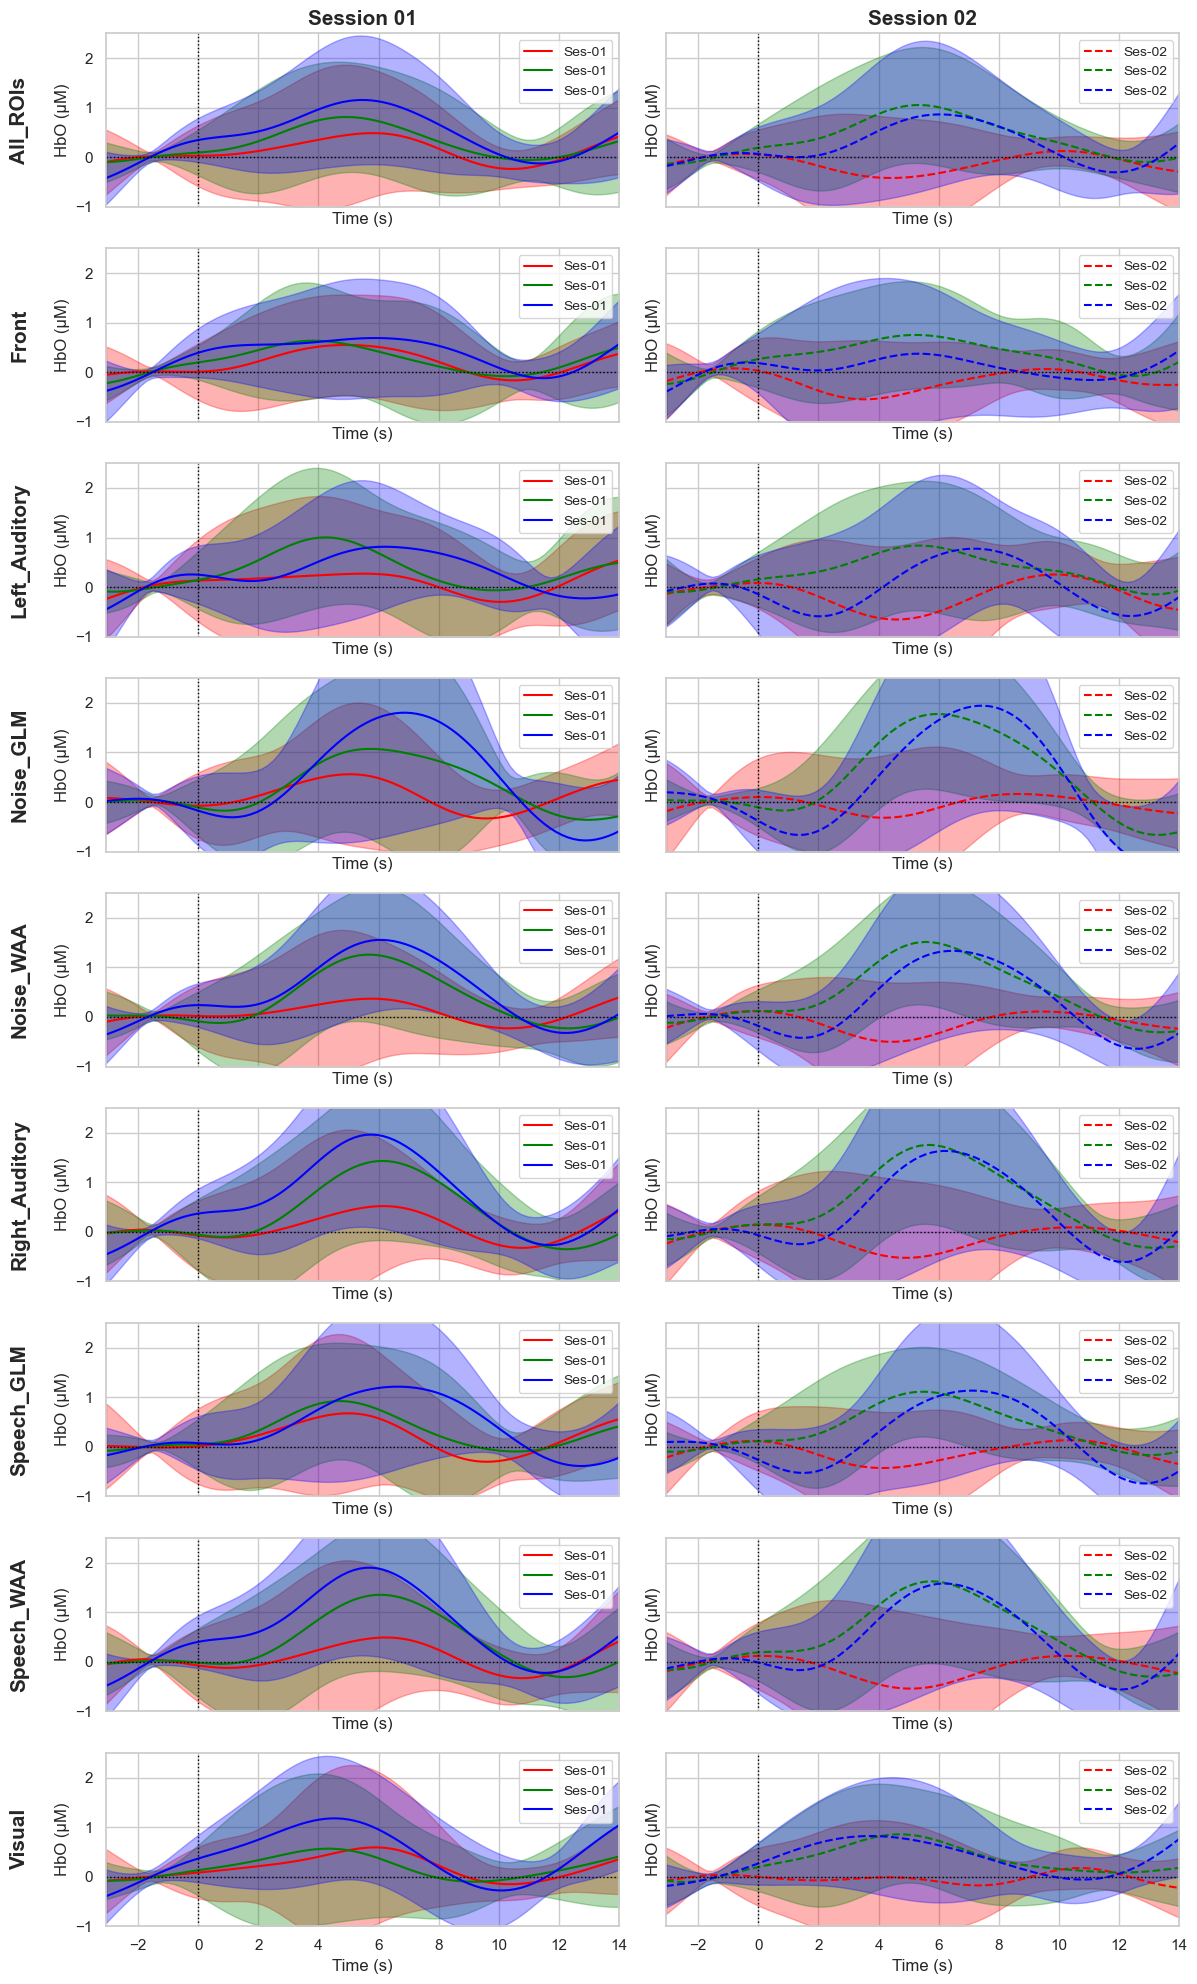

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Plot settings
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=9, ncols=2, figsize=(12, 20), sharex=True, sharey=True)
fig_dir = "group_level_plots"
os.makedirs(fig_dir, exist_ok=True)

# Define ROIs and session mapping
all_rois = sorted(group_level_means.keys())
session_titles = {1: "Session 01", 2: "Session 02"}

# Define condition-color mapping
condition_colors = {
    "Control": "red",
    "Noise": "green",
    "Speech": "blue",
    
}

# For storing group-level Pearson correlations
group_level_correlations = []

# Loop over ROIs and sessions to fill grid
for row_idx, roi_name in enumerate(all_rois):
    for col_idx, session in enumerate([1, 2]):
        ax = axes[row_idx, col_idx]

        # Track if anything is plotted
        has_data = False

        for condition, color in condition_colors.items():
            if condition not in group_level_means[roi_name]:
                continue
            if session not in group_level_means[roi_name][condition]:
                continue

            signal = group_level_means[roi_name][condition][session] * 1e6
            std = group_level_stds[roi_name][condition][session] * 1e6

            # Plot the mean line with appropriate linestyle
            ax.plot(time_vector, signal,
                    color=condition_colors[condition],
                    linestyle= '-' if session == 1 else '--',
                    linewidth=1.5,
                    label=f"Ses-0{session}")

            # Plot the shaded std region (alpha controls transparency)
            ax.fill_between(time_vector,
                            signal - std,
                            signal + std,
                            color=condition_colors[condition],
                            alpha=0.3)


            
            has_data = True

        # Add zero lines
        ax.axhline(0, color="black", linestyle=":", linewidth=1)
        ax.axvline(0, color="black", linestyle=":", linewidth=1)

        ax.set_ylim([-1, 2.5])
        ax.set_xlim([time_vector[0], time_vector[-1]])

        if col_idx == 0:
            # Add ROI label on the left
            ax.set_ylabel("")
            ax.text(-0.15, 0.5, roi_name, va="center", ha="right", rotation=90,
                    transform=ax.transAxes, fontsize=15, fontweight="bold")

        if row_idx == 0:
            # Add session title on top
            ax.set_title(session_titles[session], fontsize=15, fontweight="bold")

       
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("HbO (µM)")

       
        ax.legend(loc="upper right", fontsize="small")

        

# Adjust layout and save
plt.tight_layout()
grid_fig_path = os.path.join(fig_dir, "group_level_grid.png")
plt.savefig(grid_fig_path, dpi=300)


✅ Grid figure saved at: group_level_plots\group_level_grid.png


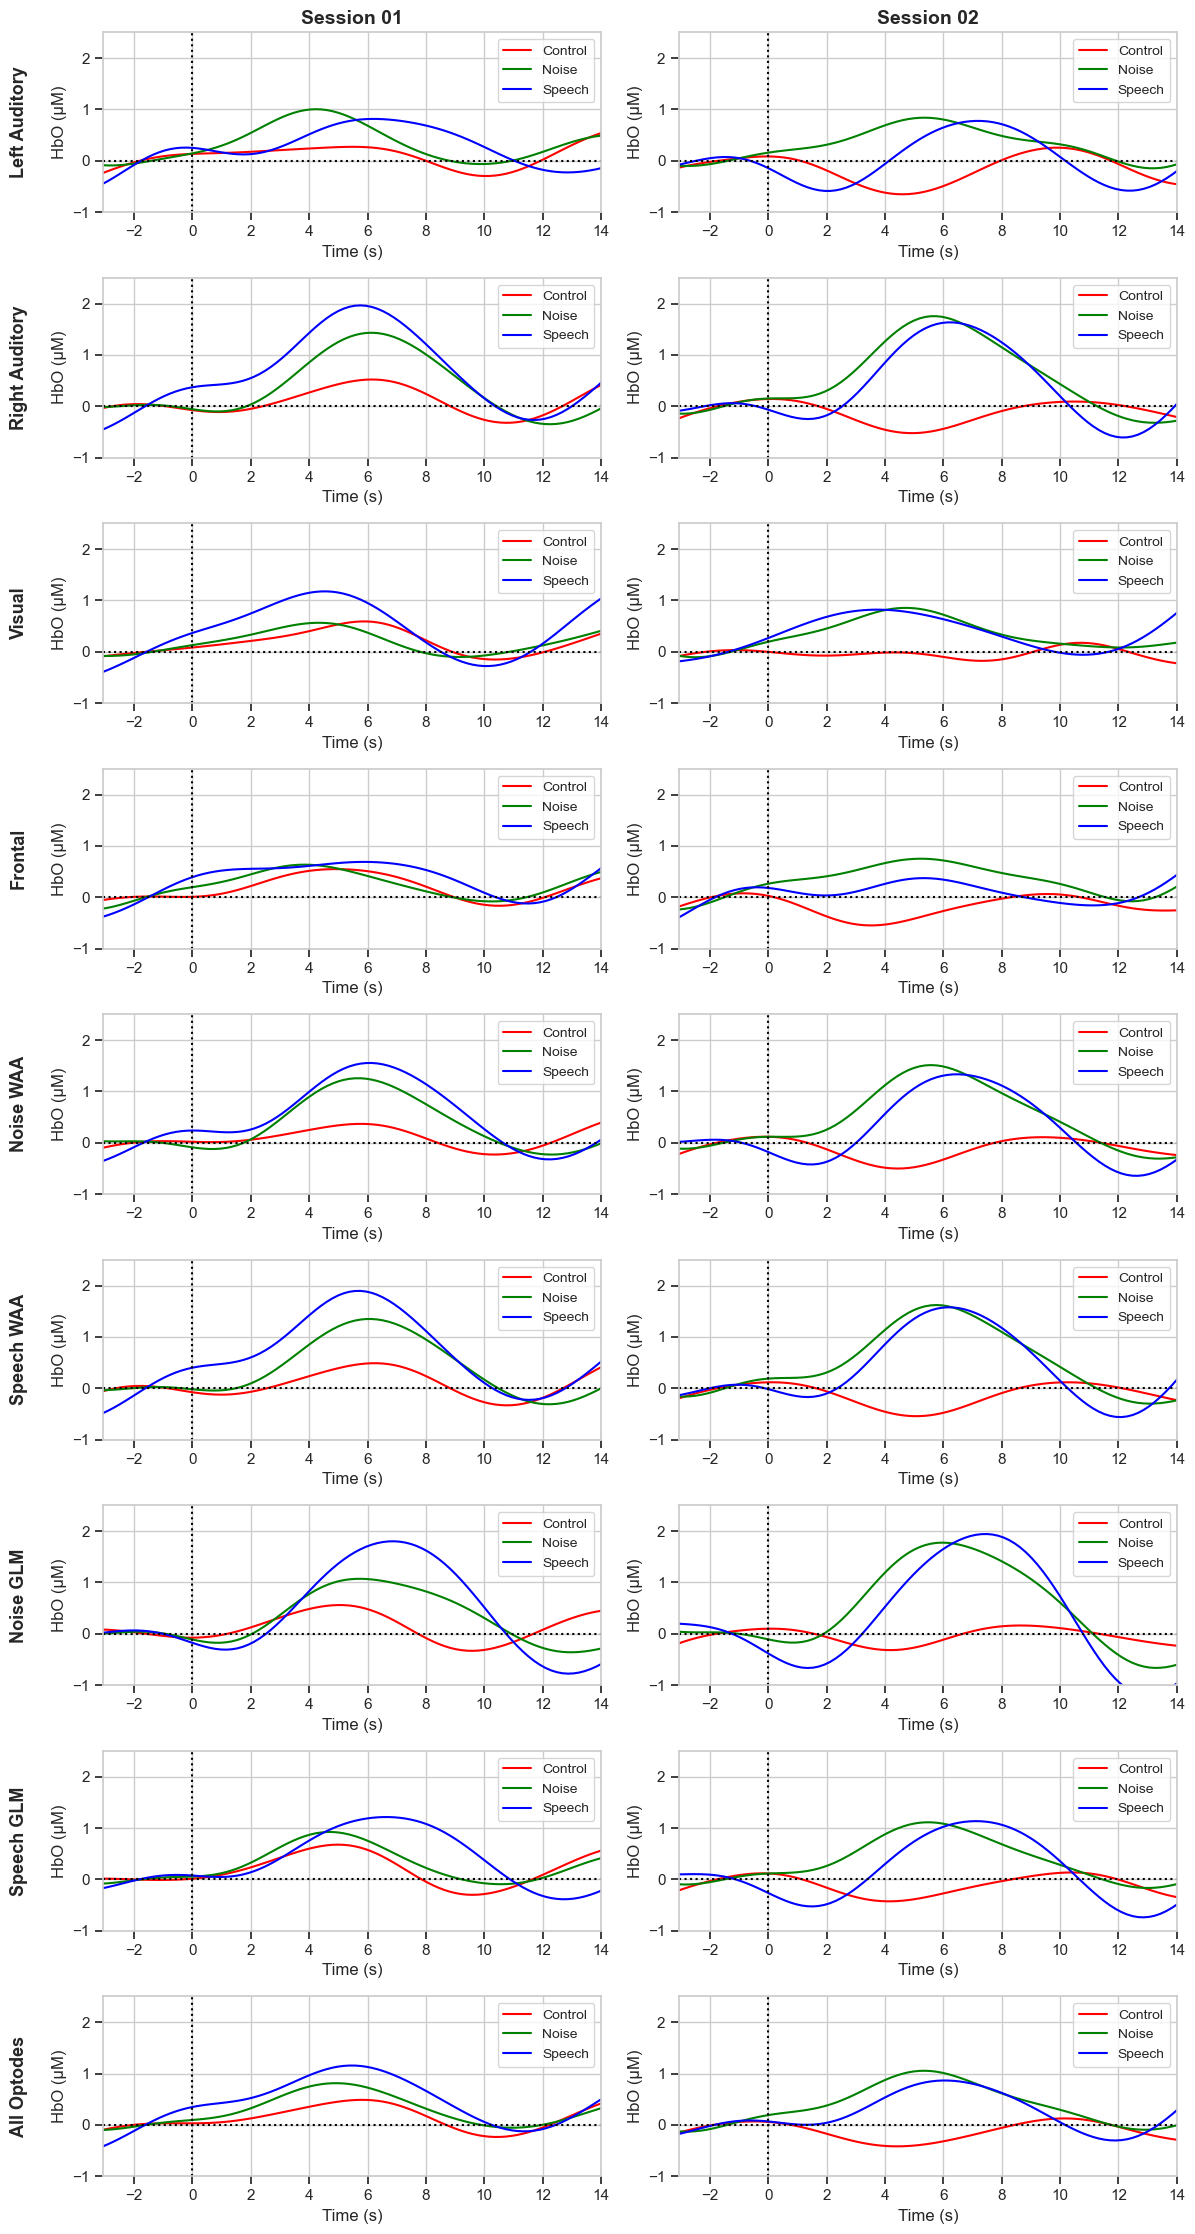

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Plot settings
sns.set(style="whitegrid")
fig_dir = "group_level_plots"
os.makedirs(fig_dir, exist_ok=True)

# ======= ✅ Define ROIs in desired order and names to display =======
roi_display_names = {
    
    "Left_Auditory": "Left Auditory",
    "Right_Auditory": "Right Auditory",
    "Visual": "Visual",
    "Front": "Frontal",
    "Noise_WAA": "Noise WAA",
    "Speech_WAA": "Speech WAA",
    "Noise_GLM": "Noise GLM",
    "Speech_GLM": "Speech GLM",
    "All_ROIs": "All Optodes"
}

# You control the order of ROIs here:
ordered_rois = [
    
    "Left_Auditory",
    "Right_Auditory",
    "Visual",
    "Front",
    
    "Noise_WAA",
    "Speech_WAA",
    "Noise_GLM",
    "Speech_GLM",
    
    "All_ROIs"
]

n_rows = len(ordered_rois)
fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(12, 2.5 * n_rows), sharex=True, sharey=True)

session_titles = {1: "Session 01", 2: "Session 02"}

condition_colors = {
    "Control": "red",
    "Noise": "green",
    "Speech": "blue",
}

# Store group-level Pearson correlations
group_level_correlations = []

for row_idx, roi_name in enumerate(ordered_rois):
    for col_idx, session in enumerate([1, 2]):
        ax = axes[row_idx, col_idx]

        for condition, color in condition_colors.items():
            if condition not in group_level_means.get(roi_name, {}):
                continue
            if session not in group_level_means[roi_name][condition]:
                continue

            signal = group_level_means[roi_name][condition][session] * 1e6  # Convert to µM
            ax.plot(time_vector, signal, color=color, linewidth=1.5, label=condition)

        # Axes formatting
        ax.axhline(0, color="black", linestyle=":", linewidth=1.5)
        ax.axvline(0, color="black", linestyle=":", linewidth=1.5)
        ax.set_ylim([-1, 2.5])
        ax.set_xlim([time_vector[0], time_vector[-1]])

        if col_idx == 0:
            display_name = roi_display_names.get(roi_name, roi_name)
            ax.text(-0.15, 0.5, display_name, va="center", ha="right", rotation=90,
                    transform=ax.transAxes, fontsize=13, fontweight="bold")

        if row_idx == 0:
            ax.set_title(session_titles[session], fontsize=14, fontweight="bold")

        ax.set_xlabel("Time (s)")
        ax.set_ylabel("HbO (µM)")
        # show the x_axis ticks
        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
        ax.tick_params(axis='y', which='both', left=True, right=False, labelleft=True, labelright=False)
        ax.legend(loc="upper right", fontsize="small")

# Adjust layout and save
plt.tight_layout()
grid_fig_path = os.path.join(fig_dir, "group_level_grid.png")
plt.savefig(grid_fig_path, dpi=300)
print(f"✅ Grid figure saved at: {grid_fig_path}")


In [16]:
condition_colors = {
    "Control": "#e41a1c",  # base red
    "Noise": "#4daf4a",    # base green
    "Speech": "#377eb8"    # base blue
}

# Better visibility for light shades
condition_shades = {
    "Control": {
        1: "#fd0000",  # light but visible red
        2: "#620000",  # dark red
    },
    "Noise": {
        1: "#00ff0d",  # light but visible green
        2: "#005606",  # dark green
    },
    "Speech": {
        1: "#008cfe",  # light but visible blue
        2: "#002459",  # dark blue
    }
}


✅ Saved to: group_level_plots\group_level_condition_comparison_grid.png


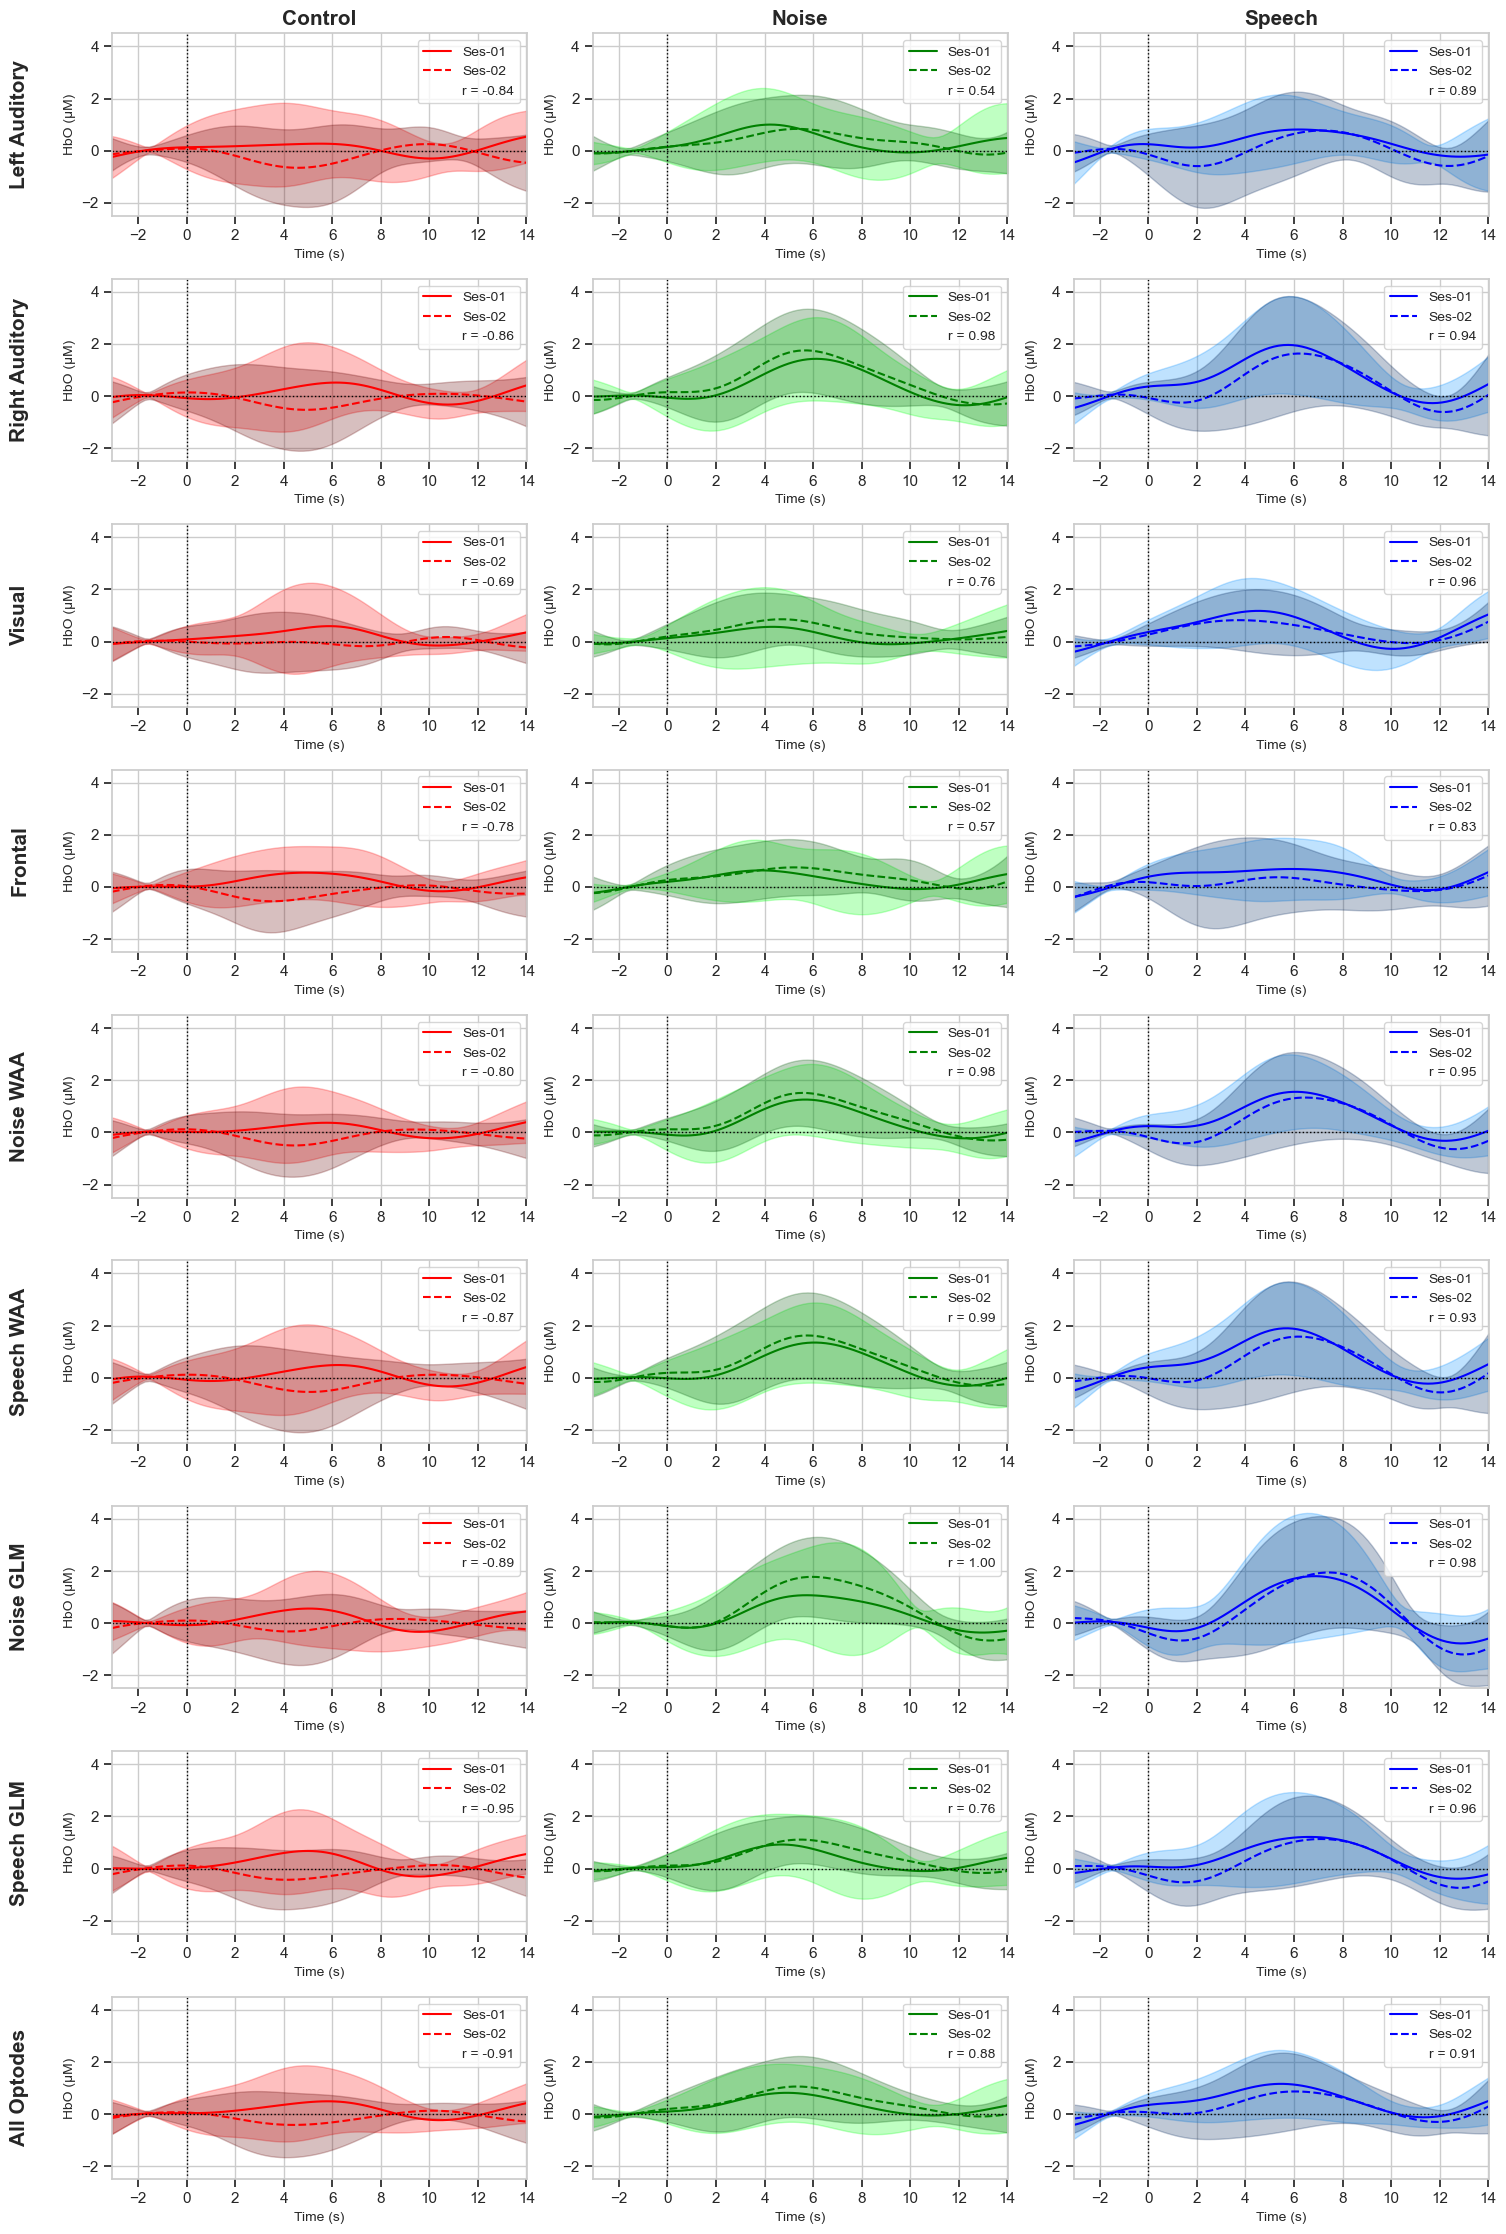

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import pandas as pd  # Only if saving the CSV at the end

# Plot settings
sns.set(style="whitegrid")
fig_dir = "group_level_plots"
os.makedirs(fig_dir, exist_ok=True)

roi_display_names = {
    "Left_Auditory": "Left Auditory",
    "Right_Auditory": "Right Auditory",
    "Visual": "Visual",
    "Front": "Frontal",
    "Noise_WAA": "Noise WAA",
    "Speech_WAA": "Speech WAA",
    "Noise_GLM": "Noise GLM",
    "Speech_GLM": "Speech GLM",
    "All_ROIs": "All Optodes"
}

ordered_rois = [
    "Left_Auditory", "Right_Auditory", "Visual", "Front",
    "Noise_WAA", "Speech_WAA", "Noise_GLM", "Speech_GLM", "All_ROIs"
]

conditions_to_plot = ["Control", "Noise", "Speech"]
condition_colors = {
    "Control": "red",
    "Noise": "green",
    "Speech": "blue",
}

n_rows = len(ordered_rois)
n_cols = len(conditions_to_plot)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 2.5 * n_rows), sharex=True, sharey=True)

group_level_correlations = []

for row_idx, roi_name in enumerate(ordered_rois):
    for col_idx, condition in enumerate(conditions_to_plot):
        ax = axes[row_idx, col_idx] if n_rows > 1 else axes[col_idx]
        display_name = roi_display_names.get(roi_name, roi_name)

        r_val = None  # To store Pearson r
        try:
            ts1 = group_level_means[roi_name][condition][1]
            ts2 = group_level_means[roi_name][condition][2]
            mask = (time_vector >= 0) & (time_vector <= 15)
            r_val, _ = pearsonr(ts1[mask], ts2[mask])
            group_level_correlations.append({
                "ROI": roi_name,
                "Condition": condition,
                "Pearson_r": r_val
            })
        except KeyError:
            pass

        # Plot sessions
        # Plot sessions with styled shading
        for session, style in zip([1, 2], ['-', '--']):
            try:
                signal = group_level_means[roi_name][condition][session] * 1e6
                std = group_level_stds[roi_name][condition][session] * 1e6

                # Mean line (always base color)
                ax.plot(time_vector, signal,
                        color=condition_colors[condition],
                        linestyle=style,
                        linewidth=1.5,
                        label=f"Ses-0{session}")

                # Shaded std (lighter/darker per session)
                ax.fill_between(time_vector,
                                signal - std,
                                signal + std,
                                color=condition_shades[condition][session],
                                alpha=0.25)

            except KeyError:
                continue


        # Add correlation info as its own legend entry
        if r_val is not None:
            ax.plot([], [], color="black", linestyle="none", label=f"r = {r_val:.2f}")


        # Axes formatting
        ax.axhline(0, color="black", linestyle=":", linewidth=1)
        ax.axvline(0, color="black", linestyle=":", linewidth=1)
        ax.set_ylim([-2.5, 4.5])
        ax.set_xlim([time_vector[0], time_vector[-1]])

        if col_idx == 0:
            # Move ROI title a bit further left (from -0.15 to -0.2)
            ax.text(-0.2, 0.5, display_name, va="center", ha="right", rotation=90,
                    transform=ax.transAxes, fontsize=15, fontweight="bold")

        if row_idx == 0:
            ax.set_title(condition, fontsize=15, fontweight="bold")

        ax.set_xlabel("Time (s)", fontsize=10)
        ax.set_ylabel("HbO (µM)", fontsize=10)
        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
        ax.tick_params(axis='y', which='both', left=True, right=False, labelleft=True, labelright=False)
        

        ax.legend(loc="upper right", fontsize="small")

# Finalize and save
plt.tight_layout()
grid_fig_path = os.path.join(fig_dir, "group_level_condition_comparison_grid.png")
plt.savefig(grid_fig_path, dpi=300)
print(f"✅ Saved to: {grid_fig_path}")




In [15]:
# Assume `correlation_df` is already created
# It must have columns: Subject, ROI, Condition, Pearson_r

import pandas as pd

# Define desired column order and mapping
roi_order = [
    "Left_Auditory", "Right_Auditory", "Visual", "Front",
    "Noise_WAA", "Speech_WAA", "Noise_GLM", "Speech_GLM", "All_ROIs"
]


roi_name_map  = {
    "Left_Auditory": "Left_Auditory",
    "Right_Auditory": "Right_Auditory",
    "Visual": "Visual",
    "Front": "Front",
    "Noise_WAA": "Noise_WAA",
    "Speech_WAA": "Speech_WAA",
    "Noise_GLM": "Noise_GLM",
    "Speech_GLM": "Speech_GLM",
    "All_ROIs": "All_ROIs"
}

# Ensure Subject is numeric for sorting and display
correlation_df["Subject_num"] = correlation_df["Subject"].astype(str).str.extract(r"(\d+)").astype(int)

# Convert ROI to consistent naming
correlation_df["ROI_clean"] = correlation_df["ROI"].map(roi_name_map)

# Create the LaTeX table rows per condition
for condition in ["Control", "Noise", "Speech"]:
    print(f"\\multicolumn{{10}}{{l}}{{\\textbf{{{condition.upper()}}}}} \\\\")
    
    rows = []
    for sub in sorted(correlation_df["Subject_num"].unique()):
        row_values = [str(sub)]
        for roi in roi_order:
            match = correlation_df[
                (correlation_df["Subject_num"] == sub) &
                (correlation_df["Condition"] == condition) &
                (correlation_df["ROI_clean"] == roi)
            ]
            if not match.empty:
                val = f"{match['Pearson_r'].values[0]:.2f}"
            else:
                val = ""
            row_values.append(val)
        print(" & ".join(row_values) + r" \\")
    
    # Mean row
    row_values = ["Mean"]
    for roi in roi_order:
        subset = correlation_df[
            (correlation_df["Condition"] == condition) &
            (correlation_df["ROI_clean"] == roi)
        ]
        if not subset.empty:
            mean_val = subset["Pearson_r"].mean()
            row_values.append(f"{mean_val:.2f}")
        else:
            row_values.append("")
    print(" & ".join(row_values) + r" \\")
    print()

\multicolumn{10}{l}{\textbf{CONTROL}} \\
1 & 0.46 & 0.24 & -0.43 & 0.12 & 0.45 & 0.30 & 0.17 & 0.44 & 0.19 \\
2 & 0.61 & 0.74 & 0.21 & 0.88 & 0.73 & 0.69 & 0.08 & 0.65 & 0.82 \\
3 & -0.14 & -0.50 & -0.31 & -0.70 & -0.32 & -0.49 & -0.47 & -0.16 & -0.43 \\
4 & 0.30 & 0.02 & -0.49 & 0.35 & 0.28 & 0.27 & -0.36 & 0.05 & 0.29 \\
5 & -0.79 & -0.74 & -0.47 & -0.62 & -0.86 & -0.63 & -0.60 & -0.98 & -0.94 \\
7 & -0.21 & -0.20 & 0.19 & -0.31 & -0.33 & -0.28 & -0.54 & -0.57 & -0.32 \\
8 & 0.74 & 0.59 & -0.21 & 0.62 & 0.24 & 0.70 & -0.18 & 0.45 & 0.16 \\
10 & 0.13 & 0.49 & 0.25 & 0.53 & 0.52 & 0.34 & 0.72 & 0.50 & 0.45 \\
11 & -0.46 & -0.60 & -0.43 & -0.57 & -0.72 & -0.47 & -0.16 & -0.25 & -0.61 \\
12 & 0.26 & 0.13 & 0.25 & 0.71 & 0.29 & 0.05 & 0.51 & 0.42 & 0.26 \\
13 & 0.07 & 0.61 & 0.62 & -0.35 & 0.15 & 0.58 & 0.44 & 0.38 & 0.15 \\
16 & -0.43 & -0.27 & 0.05 & -0.01 & -0.26 & -0.24 & -0.50 & -0.45 & -0.15 \\
17 & -0.22 & 0.07 & -0.28 & -0.81 & -0.12 & 0.08 & 0.05 & 0.34 & -0.25 \\
19 & -0.57 & -0